<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L09-Series_Multivariadas/notebooks/L09_2_Cointegracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<font color="cyan">Operación por Pares (Cointegración)</font>**

## **<font color="lightblue">Pruebas de Cointegración</font>**

### <u>Prueba de Engle-Granger</u>

La hipótesis nula de la prueba de Engle-Granger es que no existe cointegración, y concluimos que hay cointegración solo si rechazamos esta hipótesis.

$H_0:$ No existe cointegración

$H_1:$ Existe cointegración


**Pasos de esta prueba:**

1. Realizar una prueba de raíz unitaria (como Dickey-Fuller aumentada) para verificar si $y$ y $x$ tienen raíces unitarias. Si ambas son integradas del mismo orden (usualmente $I(1)$), ir al siguiente paso.

2. Ejecutar una regresión de $y$ sobre $x$ y guardar los residuos.

3. Realizar una prueba de raíz unitaria sobre los residuos (sin incluir constante ni tendencia).

4. Si se rechaza la hipótesis de raíz unitaria, concluimos que $y$ y $x$ están cointegradas. Si no se rechaza, concluimos que no hay cointegración.

Por lo tanto, si $y_t$ y $x_t$ están cointegradas, en $y_t = \alpha + \beta x_t + \epsilon_t$, el término de error $\epsilon_t$ será $I(0)$. Si no, $\epsilon_t$ será $I(1)$. Así, se puede probar la existencia de cointegración evaluando la raíz unitaria en los residuos OLS.

### <u>Prueba de Phillips-Ouliaris</u>

La prueba de Engle-Granger asume que los errores de regresión son independientes y con varianza constante, lo cual raramente ocurre en la práctica. La prueba de Phillips-Ouliaris mejora la prueba de Engle-Granger al considerar errores que no son ruido blanco (utilizando un marco Phillips-Perron).

$H_0$: No existe cointegración

$H_1$: Existe cointegración

### <u>Prueba de Johansen</u>

Otra mejora sobre la prueba de Engle-Granger es la prueba desarrollada por Johansen, la cual permite detectar múltiples vectores de cointegración (útil en modelos con más de dos variables).

## **<font color="lightblue">Pairs Trading (Operación por Pares)</font>**

Recordemos que si dos series de tiempo están cointegradas, permanecen "cerca" una de la otra en el largo plazo. En otras palabras, el spread (residuo OLS) entre ellas, $z_t = y_{t}-\beta x_{t}$ es media-revertiente.

Esta propiedad de reversión a la media del spread puede aprovecharse para hacer operaciones de trading, y comúnmente se conoce como "pairs trading" o "arbitraje estadístico".

**¿Cómo funciona?**

Se asume que el spread $z_t = y_{t}-\beta x_{t}$ es estacionario o media-revertiente con media cero.



### <u>Escenario 1:</u> El spread es bajo $z_t < -s_0$

Esto sugiere que la acción $y$ está infravalorada y la acción $x$ sobrevalorada.

**Estrategia - Comprar el spread:**

**Comprar la acción $y$. Vender en corto la acción $x$.**

Cerrar las posiciones cuando el spread vuelva a cero después de $n$ periodos (es decir $z_{t+n}=0$).


### <u>Escenario 2:</u> El spread es alto $z_t > s_0$

Esto sugiere que la acción $y$ está sobrevalorada y la acción $x$ infravalorada.

**Estrategia - Vender el spread:**

**Vender en corto la acción $y$. Comprar la acción $x$.**

Cerrar las posiciones cuando el spread vuelva a cero después de $n$ periodos (es decir $z_{t+n}=0$)

### <u>Diseño del Pairs Trading</u>

#### 1.  Selección de Pares

Identificar pares de acciones que potencialmente estén cointegradas.

Criterios comunes para seleccionar los pares:

- Pertenencia al mismo sector o industria.

- Comportamiento histórico similar en precios.

- Alta correlación como punto de partida (aunque correlación $\ne$ cointegración).

#### 2. Prueba de Cointegración

Verificar si los pares seleccionados están efectivamente cointegrados.

Aplicar pruebas estadísticas como:

- Engle-Granger

- Phillips-Ouliaris

- Johansen

Si la cointegración se confirma, se puede considerar que los precios tienen una relación de largo plazo estable.

#### 3. Diseño de la Estrategia de Trading

Estudiar la dinámica del spread entre las dos acciones:

$z_t = y_{t}-\beta x_{t}$

Establecer reglas claras de trading:

- **Umbrales de entrada** (por ejemplo, cuando $z_t$ supera $\pm 2$ o $\pm 3$ desviaciones estándar).
- **Condiciones de salida** (cuando $z_t$ revierte a la media o a un valor objetivo).
- **Gestión del riesgo** (stop-loss, tamaño de la posición, etc.).

El objetivo es explotar las desviaciones temporales del equilibrio para obtener beneficios cuando el spread vuelve a su valor esperado.

## **<font color="lightblue">Netflix VS Amazon</font>**

Centrémonos en el par NFLX vs. AMZN, que corresponde a las acciones de Netflix y Amazon.

### Importaciones y parámetros iniciales

In [24]:
!pip install arch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_ccf
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron, cointegration, ADF


plt.style.use('dark_background')

In [25]:
# Función para graficar con efecto de brillo
def grafBrillo(ax, x, y, color, title, subtitle, xlab, ylab, secondColor ='lightgray', nGlows = 10, lwBase = 2, opacityBase = 0.8):

    fontEti = {'family':'serif','color':color,'size': 14, 'fontweight': 'semibold'}
    fontTit = {'family':'serif','color':color,'size': 25, 'fontweight': 'heavy'}
    fontSub = {'family':'serif','color':'lightgray','size': 15, 'fontstyle': 'italic', 'fontweight': 'roman'}

    # Graficar varias líneas con diferente espesor y opacidad para dar brillo
    for i in range(1, nGlows + 1):
        ax.plot(x,
                y,
                color = color,
                linewidth = lwBase + (i * 1.5),
                alpha = opacityBase / nGlows)

    # Graficar la línea principal encima
    ax.plot(x,
            y,
            linewidth = lwBase,
            color = color,
            alpha= opacityBase)

    # Títulos y subtítulos
    ax.set_title(title, fontdict = fontTit, loc='left', pad=40)
    ax.text(0.0, 1.1, subtitle, transform=ax.transAxes,
        ha='left', va='top', fontdict=fontSub)
    ax.set_xlabel(xlab, fontdict = fontEti)
    ax.set_ylabel(ylab, fontdict = fontEti)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color= secondColor)

    # Parámetros de ejes y marcas de ejes
    ax.tick_params(axis='x', colors=secondColor)
    ax.tick_params(axis='y', colors=secondColor)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
    ax.spines['left'].set_color(secondColor)
    ax.spines['bottom'].set_color(secondColor)
    ax.spines['right'].set_color(secondColor)
    ax.spines['top'].set_color(secondColor)

In [26]:
# Función gráficos Autocorrelación
def grafCF(ax, serie1, color, corrType = 'ACF', serie2 = None, lags = 20, gridColor = 'lightgray', title = 'ACF'):

    fontEti = {'family':'serif','color':color,'size': 12, 'fontweight': 'semibold'}
    fontTit = {'family':'serif','color':color,'size': 17, 'fontweight': 'heavy'}

    # Generar gráfico inicial
    if corrType == 'ACF':
      xlabel = 'Autocorrelación'
      plot_acf(serie1, ax=ax, lags=lags, title='', marker = '.', color=color, vlines_kwargs={"colors": color})
    elif corrType == 'PACF':
      xlabel = 'Autocorrelación Parcial'
      plot_pacf(serie1, ax=ax, lags=lags, title='', marker = '.', color=color, vlines_kwargs={"colors": color})
    elif corrType == 'CCF':
      xlabel = 'Correlación Cruzada'
      plot_ccf(serie1, serie2, ax=ax, lags=lags, title='', marker = '.', color=color, vlines_kwargs={"colors": color})
    else:
        print('Tipo de gráfico no reconocido')

    # Cambio de color al intervalo de confianza
    ciACF = ax.collections[1]
    ciACF.set_color(color)

    # Títulos y subtítulos
    ax.set_title(title, fontdict = fontTit, loc='left')
    ax.set_xlabel('Lags', fontdict = fontEti)
    ax.set_ylabel(xlabel, fontdict = fontEti)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color= gridColor)

    # Parámetros de ejes y marcas de ejes
    ax.tick_params(axis='x', colors=gridColor)
    ax.tick_params(axis='y', colors=gridColor)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
    ax.spines['left'].set_color(gridColor)
    ax.spines['bottom'].set_color(gridColor)
    ax.spines['right'].set_color(gridColor)
    ax.spines['top'].set_color(gridColor)

In [27]:
# La función adfuller tiene una salida en forma de tupla
# Esta función genera una impresión del resumen
def pruebaDFA(serie, nombre, alpha = 0.05):
    result = adfuller(serie)
    print(f'--- Prueba de Dickey-Fuller Aumentada para {nombre} ---')
    print(f'H0: Serie No Estacionaria (Existe Raíz Unitaria)')
    print(f'H1: Serie Estacionaria (No existe Raíz Unitaria)\n')

    print(f'Estadístico ADF: {result[0]:.4f}') # Si el estadístico es menor (más negativo) que algún valor crítico se rechaza H0
    print(f'p-value: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] <= alpha:
        print(f'Conclusión: {nombre} es estacionaria. (Se rechaza Hipótesis Nula)\n')
    else:
        print(f'Conclusión: {nombre} no es estacionaria. (No se rechaza Hipótesis Nula)\n')

### <u>Obtener precios de acciones</u>

In [28]:
# Subir archivos netflix y amazon
from google.colab import files
files.upload()

Saving netflix.csv to netflix (3).csv
Saving amazon.csv to amazon (3).csv


{'netflix (3).csv': b'"NFLX.Open","NFLX.High","NFLX.Low","NFLX.Close","NFLX.Volume","NFLX.Adjusted"\r\n53.9000015258789,54.0800018310547,51.5089988708496,52.2859992980957,44444000,52.2859992980957\r\n52.1549987792969,52.6780014038086,51.5890007019043,52.0800018310547,31339000,52.0800018310547\r\n51.1969985961914,51.310001373291,49.9500007629395,50.048999786377,53462000,50.048999786377\r\n50.8279991149902,51.6440010070801,50.6419982910156,50.8889999389648,36864000,50.8889999389648\r\n51.1310005187988,51.3240013122559,50.451000213623,51.0400009155273,29739000,51.0400009155273\r\n50.7840003967285,51.0730018615723,49.7949981689453,49.9099998474121,38062000,49.9099998474121\r\n50,50.109001159668,48.5670013427734,49.4249992370605,59904000,49.4249992370605\r\n49.5499992370605,51.2350006103516,49.3009986877441,50.7789993286133,50321000,50.7789993286133\r\n50.7350006103516,51.4500007629395,49.9580001831055,50.0859985351562,41774000,50.0859985351562\r\n50,50.6319999694824,49.5099983215332,49.798

In [29]:
dfAMZN = pd.read_csv('/content/amazon.csv')
dfAMZN.head()

,AMZN.Open,AMZN.High,AMZN.Low,AMZN.Close,AMZN.Volume,AMZN.Adjusted
0,163.500000,163.600006,157.201004,159.331497,88228000,159.331497
1,158.300507,161.169006,158.253006,160.925507,53110000,160.925507
2,157.324005,159.875504,156.557999,156.919006,87896000,156.919006
3,157.850006,160.427002,157.750000,158.108002,70290000,158.108002
4,159.000000,159.531998,157.110001,159.134995,70754000,159.134995


In [30]:
dfNFLX = pd.read_csv('/content/netflix.csv')
dfNFLX.head()

,NFLX.Open,NFLX.High,NFLX.Low,NFLX.Close,NFLX.Volume,NFLX.Adjusted
0,53.900002,54.080002,51.508999,52.285999,44444000,52.285999
1,52.154999,52.678001,51.589001,52.080002,31339000,52.080002
2,51.196999,51.310001,49.950001,50.049000,53462000,50.049000
3,50.827999,51.644001,50.641998,50.889000,36864000,50.889000
4,51.131001,51.324001,50.451000,51.040001,29739000,51.040001


In [31]:
df = pd.DataFrame({
    'AMZNCierre': dfAMZN['AMZN.Close'],
    'NFLXCierre': dfNFLX['NFLX.Close']
})

df.head()

,AMZNCierre,NFLXCierre
0,159.331497,52.285999
1,160.925507,52.080002
2,156.919006,50.049000
3,158.108002,50.889000
4,159.134995,51.040001


### <u>Análisis Inicial</u>

Graficamos los precios de cierre de NFLX y AMZN, las funciones de autocorrelación, y examinamos estacionariedad.

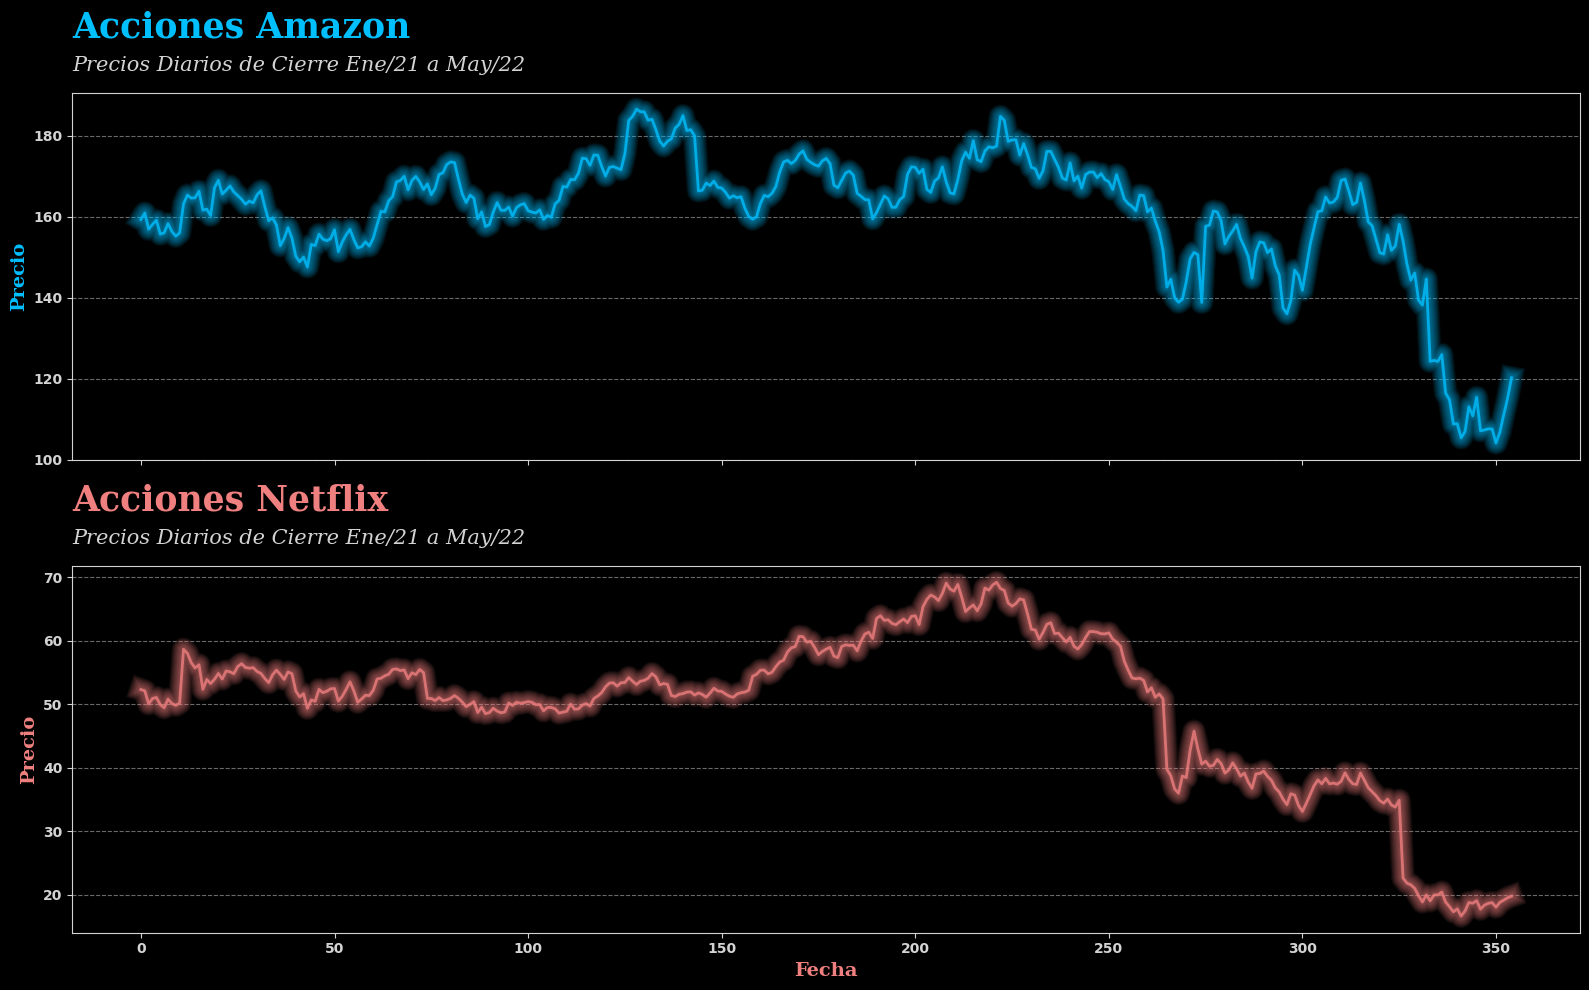

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True) # 2 filas, 1 columna

# Graficar el cierre de Amazon con efecto de brillo
grafBrillo(ax = axes[0],
                 x = df.index,
                 y = df['AMZNCierre'],
                 color = 'deepskyblue',
                 title = 'Acciones Amazon',
                 subtitle = 'Precios Diarios de Cierre Ene/21 a May/22',
                 xlab = '',
                 ylab = 'Precio')

# Graficar el cierre de Netflix con efecto de brillo usando un color diferente
grafBrillo(ax = axes[1],
                 x = df.index,
                 y = df['NFLXCierre'],
                 color = 'lightcoral',
                 title = 'Acciones Netflix',
                 subtitle = 'Precios Diarios de Cierre Ene/21 a May/22',
                 xlab = 'Fecha',
                 ylab = 'Precio')
plt.tight_layout()
plt.show()

Los gráficos de series de tiempo de Netflix y Amazon no muestran estacionariedad: Hay una disminución general en los precios desde 2021.

Parece que la varianza cambia con el tiempo; utilizaremos una **transformación logarítmica.**

In [33]:
df['AMZN_log'] = np.log(df['AMZNCierre'])
df['NFLX_log'] = np.log(df['NFLXCierre'])

df.head()

,AMZNCierre,NFLXCierre,AMZN_log,NFLX_log
0,159.331497,52.285999,5.070987,3.956729
1,160.925507,52.080002,5.080942,3.952781
2,156.919006,50.049000,5.055730,3.913003
3,158.108002,50.889000,5.063278,3.929647
4,159.134995,51.040001,5.069753,3.932610


A continuación revisemos las funciones de autocorrelación.

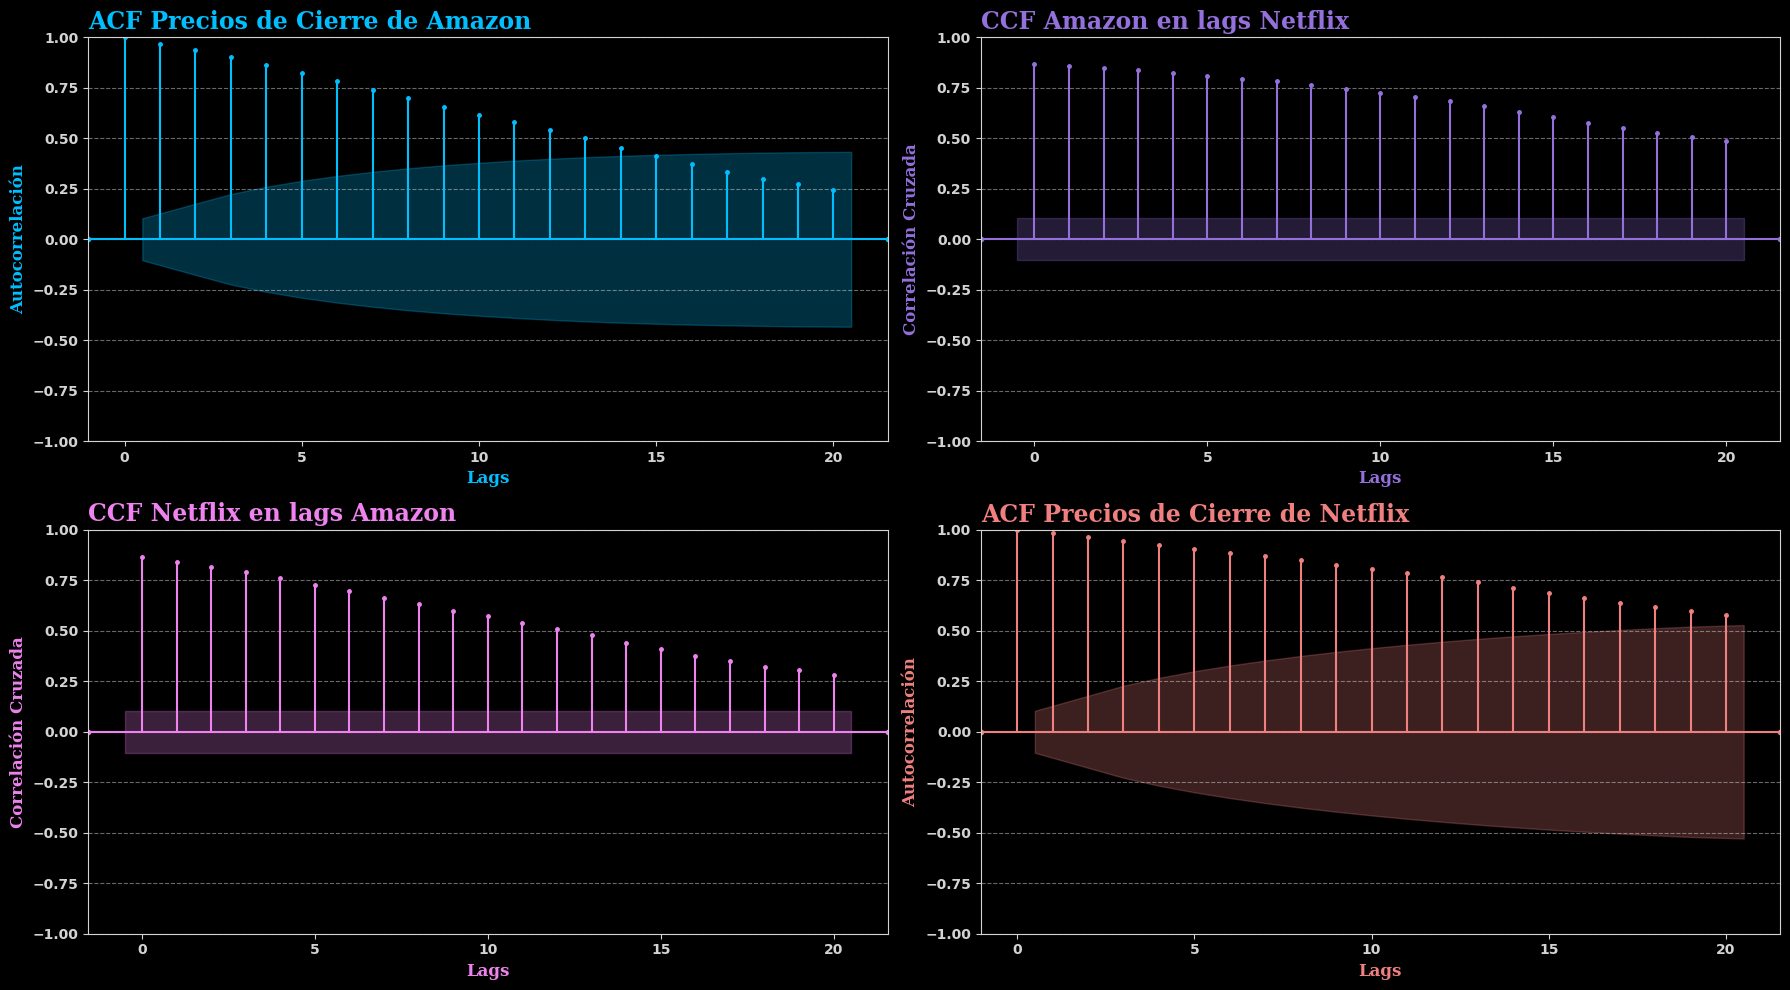

In [34]:
# Crear una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Gráfico 1: Función de Autocorrelación (ACF) para AMZNCierre
grafCF(ax = axes[0, 0],
       serie1 = df['AMZN_log'],
       corrType = 'ACF',
       color = 'deepskyblue',
       title='ACF Precios de Cierre de Amazon')

# Gráfico 2: Función de Correlación Cruzada (CCF) entre AMZN y NFLX
grafCF(ax = axes[0 ,1],
        serie1 = df['AMZN_log'],
        serie2 = df['NFLX_log'],
        corrType = 'CCF',
        color = 'mediumpurple',
        title='CCF Amazon en lags Netflix')

# Gráfico 3: Función de Correlación Cruzada (CCF) entre NFLX y AMZN
grafCF(ax = axes[1, 0],
       serie1 = df['NFLX_log'],
       serie2 = df['AMZN_log'],
       corrType = 'CCF',
       color = 'violet',
       title='CCF Netflix en lags Amazon')

# Gráfico 4: Función de Autocorrelación (ACF) para NFLXCierre
grafCF(ax = axes[1,1],
       serie1 = df['NFLX_log'],
       corrType = 'ACF',
       color = 'lightcoral',
       title='ACF Precios de Cierre de Netflix')

plt.tight_layout()
plt.show()

Las funciones de autocorrelación (ACF) decaen muy lentamente, lo cual sugiere que estas series podrían tener una raíz unitaria.

Además, a partir de los gráficos de correlación cruzada, podemos ver que la correlación entre los precios de cierre de Amazon y Netflix es positiva.

Pero debemos tener cuidado. Esta correlación positiva podría deberse a tendencias estocásticas “ocultas” en estas variables. Debemos verificar si están cointegradas o no.

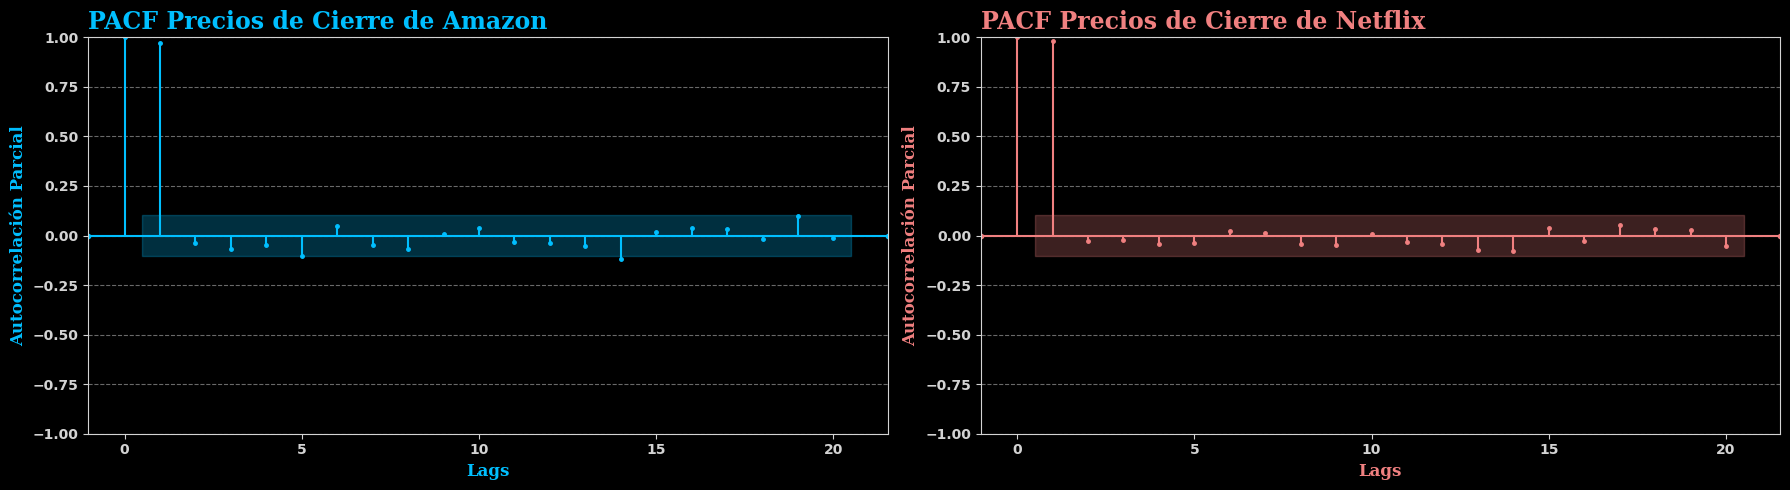

In [35]:
# Crear una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Gráfico 1: Función de Autocorrelación (ACF) para AMZNCierre
grafCF(ax = axes[0],
       serie1 = df['AMZN_log'],
       corrType = 'PACF',
       color = 'deepskyblue',
       title='PACF Precios de Cierre de Amazon')

# Gráfico 2: Función de Autocorrelación (ACF) para NFLXCierre
grafCF(ax = axes[1],
       serie1 = df['NFLX_log'],
       corrType = 'PACF',
       color = 'lightcoral',
       title='PACF Precios de Cierre de Netflix')

plt.tight_layout()
plt.show()

Las funciones de Autocorrelación parcial sugieren nuevamente una raíz unitaria por lo que procederemos a hacer pruebas formales.

### <u>Pruebas de raíz Unitaria</u>

Realizamos pruebas de raíz unitaria para los precios de cierre de NFLX y AMZN.


¿Son estacionarias? ¿Están ambas integradas del mismo orden?

In [36]:
pruebaDFA(df['AMZN_log'], 'log(AMZN)')
pruebaDFA(df['NFLX_log'], 'log(NFLX)')

--- Prueba de Dickey-Fuller Aumentada para log(AMZN) ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -1.0547
p-value: 0.7328
Valores Críticos:
   1%: -3.4490
   5%: -2.8697
   10%: -2.5711
Conclusión: log(AMZN) no es estacionaria. (No se rechaza Hipótesis Nula)

--- Prueba de Dickey-Fuller Aumentada para log(NFLX) ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: 0.6940
p-value: 0.9897
Valores Críticos:
   1%: -3.4490
   5%: -2.8697
   10%: -2.5711
Conclusión: log(NFLX) no es estacionaria. (No se rechaza Hipótesis Nula)



Para ambas series logarítmicas de los precios de cierre de Netflix y Amazon, el *p-value* es mucho mayor al 5%, por lo que no rechazamos la hipótesis nula de no estacionariedad.

In [37]:
df['AMZN_log_diff'] = df['AMZN_log'].diff()
df['NFLX_log_diff'] = df['NFLX_log'].diff()

pruebaDFA(df['AMZN_log_diff'].dropna(), 'log(AMZN)-Diferenciada')
pruebaDFA(df['NFLX_log_diff'].dropna(), 'log(NFLX)-Diferenciada')

--- Prueba de Dickey-Fuller Aumentada para log(AMZN)-Diferenciada ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -19.3510
p-value: 0.0000
Valores Críticos:
   1%: -3.4490
   5%: -2.8698
   10%: -2.5712
Conclusión: log(AMZN)-Diferenciada es estacionaria. (Se rechaza Hipótesis Nula)

--- Prueba de Dickey-Fuller Aumentada para log(NFLX)-Diferenciada ---
H0: Serie No Estacionaria (Existe Raíz Unitaria)
H1: Serie Estacionaria (No existe Raíz Unitaria)

Estadístico ADF: -18.3221
p-value: 0.0000
Valores Críticos:
   1%: -3.4490
   5%: -2.8698
   10%: -2.5712
Conclusión: log(NFLX)-Diferenciada es estacionaria. (Se rechaza Hipótesis Nula)



En cambio, para sus primeras diferencias, ambos *p-values* son menores al 5%, y rechazamos la hipótesis nula de no estacionariedd (y por lo tanto otra raíz unitaria).

Por lo tanto, tanto los logaritmos de los precios de cierre de Amazon como de Netflix tienen una raíz unitaria y son $I(1)$. Podemos proceder al siguiente paso del análisis.

### <u>Pruebas de Cointegración</u>

Una vez determinado que ambas series son integradas en el mismo orden, podemos continuar con la prueba de Engle-Granger para cointegración.

Primero realizamos una regresión del logaritmo del precio de cierre de Netflix sobre el logaritmo del precio de cierre de Amazon, y luego aplicamos una prueba de raíz unitaria sobre los residuales.

In [38]:
# Realizar la regresión de OLS (NFLX_log como dependiente, AMZN_log como independiente)
regCoint = smf.ols(formula='NFLX_log ~ AMZN_log', data=df).fit()

# Mostrar el resumen de los resultados de la regresión
print(regCoint.summary())

                            OLS Regression Results                            
Dep. Variable:               NFLX_log   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     1060.
Date:                Fri, 03 Jul 2026   Prob (F-statistic):          2.32e-108
Time:                        01:20:10   Log-Likelihood:                 146.63
No. Observations:                 355   AIC:                            -289.3
Df Residuals:                     353   BIC:                            -281.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.0820      0.398    -22.838      0.0

In [39]:
# Guardar los valores ajustados
df['ajusteNFLX'] = regCoint.fittedvalues

# Obtener los residuales de la regresión
df['residuales'] = regCoint.resid

# Realizar la prueba de Dickey-Fuller aumentada sobre los residuos
adfResiduales = ADF(df['residuales'])
print(adfResiduales.summary())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.956
P-value                         0.039
Lags                                0
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [40]:
# Otra prueba de raíz unitaria más robusta que DFA
ppResult = PhillipsPerron(df['residuales'], trend='c')

# 3. Imprimir los resultados de la prueba
print(ppResult.summary())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.902
P-value                         0.045
Lags                               17
-------------------------------------

Trend: Constant
Critical Values: -3.45 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Con base en la prueba de raíz unitaria de Dickey-Fuller y Phillips-Perron, el p-value es menor al 5%, por lo que rechazamos la hipótesis nula de raíz unitaria en los residuos. Esto indica que la prueba de Engle Granger proporciona evidencia de que los logaritmos de los precios de cierre de Netflix y Amazon están cointegrados, ya que los residuos son estacionarios.

In [41]:
# Prueba de cointegración completa
poResult = cointegration.phillips_ouliaris(df['NFLX_log'], df['AMZN_log'])
print(poResult.summary())

Phillips-Ouliaris Zt Cointegration Test
Test Statistic                 -3.059
P-value                         0.098
Kernel                       Bartlett
Bandwidth                       7.161
-------------------------------------

Trend: Constant
Critical Values: -3.07 (10%), -3.36 (5%), -3.94 (1%)
Null Hypothesis: No Cointegration
Alternative Hypothesis: Cointegration
Distribution Order: 3


También podemos utilizar una prueba de cointegración más robusta, como la prueba de cointegración de Phillips-Ouliaris. Según esta prueba, no se rechaza la hipótesis nula de que no existe cointegración al 5% de significancia, pero sí se rechaza al 10%.

### <u>Estrategia</u>

Graficar el spread (residuo) y discutir una posible estrategia de trading.

In [42]:
df.head()

,AMZNCierre,NFLXCierre,AMZN_log,NFLX_log,AMZN_log_diff,NFLX_log_diff,ajusteNFLX,residuales
0,159.331497,52.285999,5.070987,3.956729,NaN,NaN,3.852721,0.104008
1,160.925507,52.080002,5.080942,3.952781,0.009955,-0.003948,3.878112,0.074669
2,156.919006,50.049000,5.055730,3.913003,-0.025212,-0.039779,3.813804,0.099198
3,158.108002,50.889000,5.063278,3.929647,0.007549,0.016644,3.833058,0.096588
4,159.134995,51.040001,5.069753,3.932610,0.006475,0.002963,3.849573,0.083037


El spread corresponderá a los residuales $e_t$ de nuestro modelo de regresión $ln(NFLX)_t = \beta_0 + \beta_1 ln(AMZN)_t + e_t$

In [43]:
df.rename(columns={'residuales': 'spread'}, inplace=True)
df.head()

,AMZNCierre,NFLXCierre,AMZN_log,NFLX_log,AMZN_log_diff,NFLX_log_diff,ajusteNFLX,spread
0,159.331497,52.285999,5.070987,3.956729,NaN,NaN,3.852721,0.104008
1,160.925507,52.080002,5.080942,3.952781,0.009955,-0.003948,3.878112,0.074669
2,156.919006,50.049000,5.055730,3.913003,-0.025212,-0.039779,3.813804,0.099198
3,158.108002,50.889000,5.063278,3.929647,0.007549,0.016644,3.833058,0.096588
4,159.134995,51.040001,5.069753,3.932610,0.006475,0.002963,3.849573,0.083037


In [44]:
mediaSpread = df['spread'].mean()
desvSpread = df['spread'].std()

print(f'Media del spread: {mediaSpread:.2f}')
print(f'Desviación estándar del spread: {desvSpread:.4f}')

Media del spread: -0.00
Desviación estándar del spread: 0.1603


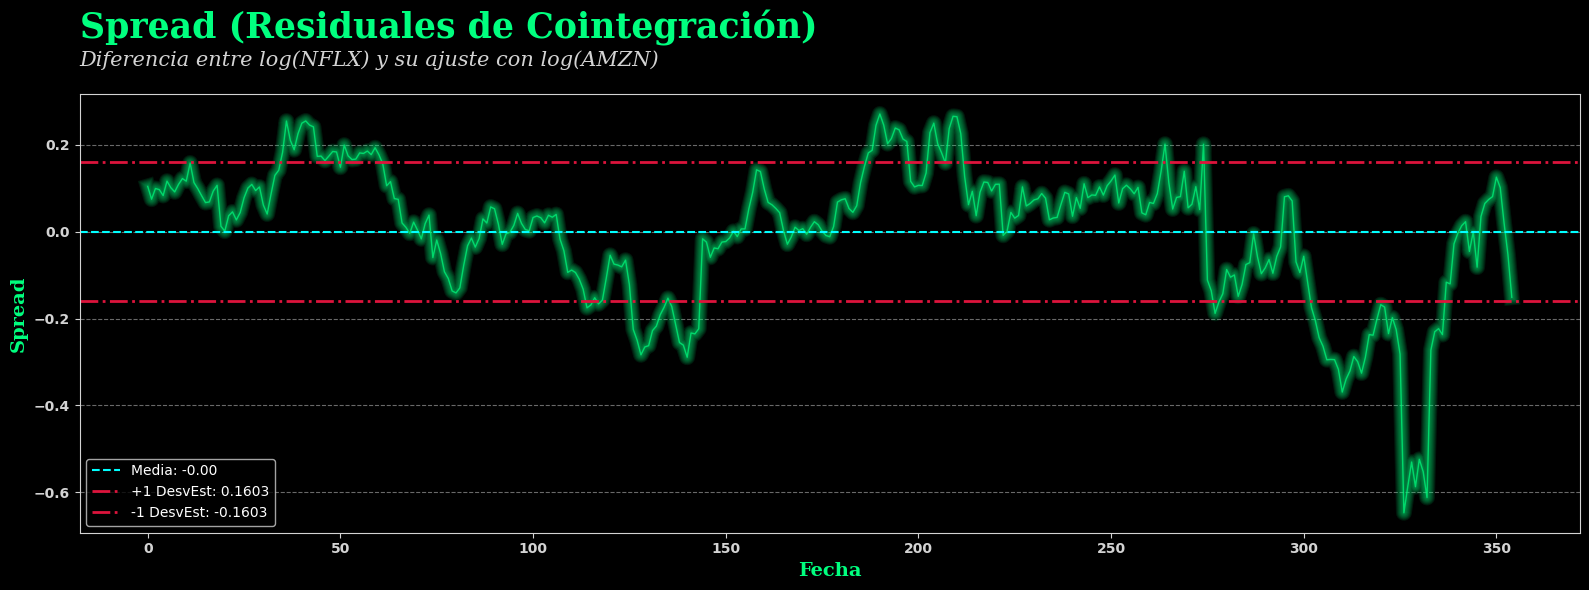

In [45]:
fig, ax = plt.subplots(figsize=(16, 6))
grafBrillo(ax=ax,
           x=df.index,
           y=df['spread'],
           color='springgreen',
           title='Spread (Residuales de Cointegración)',
           subtitle='Diferencia entre log(NFLX) y su ajuste con log(AMZN)',
           xlab='Fecha', ylab='Spread',
           nGlows = 7, lwBase = 1, opacityBase = 0.7)

# Agregar línea horizontal en la media del spread
ax.axhline(mediaSpread, color='aqua', linestyle='--', linewidth = 1.5, label=f'Media: {mediaSpread:.2f}')

# Agregar líneas horizontales en +/- desviación estándar
ax.axhline(desvSpread, color='crimson', linestyle='-.', linewidth = 2, label=f'+1 DesvEst: {desvSpread:.4f}')
ax.axhline(-desvSpread, color='crimson', linestyle='-.', linewidth = 2, label=f'-1 DesvEst: {-desvSpread:.4f}')

ax.legend()

plt.tight_layout()
plt.show()

Al analizar el spread de los residuos, podemos definir señales de trading para abrir y cerrar posiciones. Podemos usar las desviaciones estándar del spread como umbrales.

Por ejemplo, consideremos que nuestras señales de trading se basan en una desviación estándar de los residuos, es decir, $+\sigma = 0.1603$ y $-\sigma = -0.1603$, respectivamente.

Entonces, nuestra estrategia sería la siguiente:

- Cuando el spread está por encima de $+\sigma = 0.1603$, esto significa que Netflix está sobrevaluado en comparación con Amazon, por lo tanto, vendemos NFLX y compramos AMZN.

- Cuando el spread está por debajo de $-\sigma = -0.1603$, esto indica que Netflix está subvaluado respecto a Amazon, por lo tanto, compramos NFLX y vendemos AMZN.

Y siempre que el spread vuelva a converger hacia $\mu = 0$, cerramos la posición.